# 00 -- Scientific Python and reproducible numerics

| question | answer |
|---|---|
| What physics problem? | A measurement or simulation must give the same number twice. |
| What mathematics? | Floating-point arithmetic, rounding error, and error growth. |
| What algorithm? | Vectorized evaluation and seeded pseudo-random number generation. |
| What software? | NumPy, SymPy, Pandas, Matplotlib; optional PyTorch. |
| What experiment? | Any experiment whose analysis pipeline must be reproducible. |
| What engineering application? | Deterministic firmware and DSP produce bit-identical results. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## English explanation

Scientific computing represents real numbers with a finite number of bits, so most values are
stored approximately. A reproducible pipeline controls three things: the numeric type (how much
precision), the order of operations (rounding is not associative), and every source of randomness
(seed the generator). This chapter fixes those habits; every later chapter depends on them.

The subject-verb-object frame: the *computer stores* an approximation, the *operation accumulates*
error, and the *seed fixes* the random stream.

## Mathematical derivation

A binary floating-point number has the form $x=\pm(1+f)\,2^{e}$ with a fixed-width fraction
$f$. The gap between consecutive representable numbers near 1 is the machine epsilon
$\varepsilon$; for IEEE-754 double precision $\varepsilon=2^{-52}\approx2.22\times10^{-16}$. A single
rounding introduces relative error at most $\varepsilon/2$. Subtracting two nearly equal numbers
$a-b$ **cancels** their leading digits and amplifies that relative error by $\frac{|a|+|b|}{|a-b|}$ --
catastrophic cancellation, the main enemy of naive formulas.

## Dimensions and SI units

Floating-point values are pure numbers; physical meaning comes from the unit attached to them.
The repository keeps that meaning explicit with `physkit.units`. Below, Planck's constant times a
frequency is checked to carry the dimension of energy before any number is trusted.

In [2]:
h = U.Quantity(C.H, U.ACTION)          # J s
f = U.Quantity(4.84e14, U.FREQUENCY)   # Hz (red light)
E = h * f
E.to_dimension(U.ENERGY)               # raises if the dimensions were wrong
print("photon energy dimension:", E.dim, "| value:", E.value, "J =", E.value / C.E, "eV")

photon energy dimension: L^2 M^1 T^-2 | value: 3.2070179526e-19 J = 2.0016631653111476 eV


## SymPy derivation

SymPy computes with exact symbols, so it is the reference against which floating point is
judged. Here the associativity failure of floating-point addition is exhibited: exactly, the sum is
order-independent; in `float`, it is not.

In [3]:
a, b, c = sp.Rational(1), sp.Rational(1, 10**16), sp.Rational(-1)
exact = (a + b) + c
print("SymPy exact ((1 + 1e-16) - 1) =", exact, "=", float(exact))
fa, fb, fc = 1.0, 1e-16, -1.0
print("float  ((1 + 1e-16) - 1) =", (fa + fb) + fc, " vs (1e-16 + (1 - 1)) =", fb + (fa + fc))
print("=> floating-point addition is not associative")

SymPy exact ((1 + 1e-16) - 1) = 1/10000000000000000 = 1e-16
float  ((1 + 1e-16) - 1) = 0.0  vs (1e-16 + (1 - 1)) = 1e-16
=> floating-point addition is not associative


## NumPy implementation

NumPy evaluates array expressions in compiled loops (vectorization): the same result as a
Python loop, produced far faster and with a fixed evaluation order. We also show a numerically stable
rewrite that avoids cancellation.

In [4]:
eps = np.finfo(np.float64).eps
print("machine epsilon (float64):", eps)

# catastrophic cancellation: sqrt(1+x) - 1 for small x
x = 1e-12
naive = np.sqrt(1 + x) - 1.0
stable = x / (np.sqrt(1 + x) + 1.0)         # algebraically identical, no cancellation
print(f"naive  = {naive:.3e}")
print(f"stable = {stable:.3e}  (reference x/2 = {x/2:.3e})")

# vectorization vs a Python loop (same numbers)
v = np.linspace(0, 1, 1_000_00)
loop = sum(vi**2 for vi in v.tolist())
vect = float(np.sum(v**2))
print("loop and vectorized agree:", np.isclose(loop, vect))

machine epsilon (float64): 2.220446049250313e-16
naive  = 5.000e-13
stable = 5.000e-13  (reference x/2 = 5.000e-13)
loop and vectorized agree: True


## Pandas tables

Pandas organizes numeric facts into tables for reporting. Here: the precision of each common
NumPy float type.

In [5]:
rows = []
for dt in (np.float16, np.float32, np.float64):
    fi = np.finfo(dt)
    rows.append({"dtype": np.dtype(dt).name, "bits": fi.bits, "eps": fi.eps,
                 "max": fi.max, "decimal_digits": fi.precision})
df = pd.DataFrame(rows)
print(df.to_string(index=False))

  dtype  bits          eps           max  decimal_digits
float16    16 9.765625e-04  6.550400e+04               3
float32    32 1.192093e-07  3.402823e+38               6
float64    64 2.220446e-16 1.797693e+308              15


## Matplotlib plots

The stable and naive formulas diverge as $x\to0$. Plotting relative error against $x$ shows the
naive form losing all significant digits once cancellation dominates.

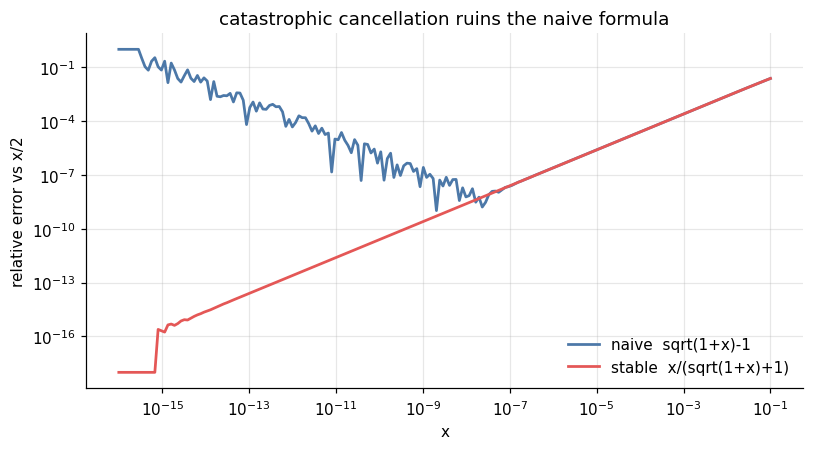

In [6]:
xs = np.logspace(-16, -1, 200)
naive = np.sqrt(1 + xs) - 1.0
stable = xs / (np.sqrt(1 + xs) + 1.0)
ref = xs / 2
plt.figure()
plt.loglog(xs, np.abs(naive - ref) / ref, label="naive  sqrt(1+x)-1")
plt.loglog(xs, np.abs(stable - ref) / ref + 1e-18, label="stable  x/(sqrt(1+x)+1)")
plt.xlabel("x"); plt.ylabel("relative error vs x/2")
plt.title("catastrophic cancellation ruins the naive formula")
plt.legend(); plt.tight_layout(); plt.show()

## PyTorch (optional)

When PyTorch is installed it provides the same arithmetic on tensors (and on a GPU). The NumPy
result stays authoritative; PyTorch is a cross-check. The cell is guarded so the notebook runs
without it.

In [7]:
if torch is not None:
    xt = torch.linspace(0, 1, 1000, dtype=torch.float64)
    print("torch sum(x^2) =", float((xt**2).sum()),
          "| numpy =", float(np.sum(np.linspace(0,1,1000)**2)))
else:
    print("PyTorch absent -- NumPy path already computed the result above.")

PyTorch absent -- NumPy path already computed the result above.


## Exercises

1. Show numerically that `0.1 + 0.2 == 0.3` is `False` in float64, and explain why using the
   binary expansion of `0.1`.
2. The quadratic formula loses precision for one root when $b^2\gg4ac$. Implement the stable variant
   using $x_1 x_2=c/a$ and compare.
3. Seed `np.random.default_rng` with a fixed value and confirm two runs produce identical arrays;
   remove the seed and confirm they differ. State why reproducibility needs the seed.

## Engineering applications

A **firmware** routine on a microcontroller must accumulate ADC samples in an order that avoids
cancellation, or a slowly drifting baseline will corrupt the sum. A **DSP** filter implemented in
fixed point chooses word length from the same $\varepsilon$ analysis. A **GPU** kernel that reduces
millions of values uses pairwise summation to bound error growth. Reproducibility -- fixed dtype,
fixed order, fixed seed -- is what lets an instrument's result be audited.

Summary (subject-verb-object): the computer stores approximations; the algorithm controls error; the
seed fixes randomness; the engineer guarantees reproducibility.